In [1]:
import osmnx as ox
import networkx as nx

import matplotlib.pyplot as plt

In [2]:
start_point = (42.3601, -71.0589)
G = ox.graph_from_point(start_point, dist=1000, network_type='walk')
origin_node = ox.nearest_nodes(G, Y=start_point[0], X=start_point[1])

In [3]:
target_distance = 10 # in meters
nodes_within_x = nx.single_source_shortest_path_length(G, origin_node, cutoff=target_distance)

In [ ]:
nodes_within_x

{7335431256: 0,
 10202926968: 1,
 7335431249: 1,
 7335431251: 1,
 10202926967: 2,
 10202926970: 2,
 11949005134: 2,
 7335431248: 2,
 7335430837: 2,
 7335431253: 2,
 10181879394: 3,
 10202926964: 3,
 10181879380: 3,
 10202926969: 3,
 11949005143: 3,
 11949005148: 3,
 6990594261: 3,
 7164877101: 3,
 7335431244: 3,
 10181879396: 4,
 10202945934: 4,
 11823068772: 4,
 10202945996: 4,
 10202946008: 4,
 10181879377: 4,
 10181879378: 4,
 11949005149: 4,
 2586592450: 4,
 11949005145: 4,
 11949005147: 4,
 6990594260: 4,
 9297897347: 4,
 7164877104: 4,
 7335430842: 4,
 4776825440: 4,
 731633442: 4,
 7335430838: 4,
 10181879397: 5,
 10199995580: 5,
 10202945935: 5,
 10181879367: 5,
 10202945969: 5,
 10202946007: 5,
 10184692908: 5,
 10202946009: 5,
 10202926965: 5,
 10202926966: 5,
 11531758312: 5,
 11949005144: 5,
 6162811462: 5,
 7335431197: 5,
 11949005135: 5,
 4132047217: 5,
 4132058407: 5,
 6162811202: 5,
 7629652917: 5,
 7629652919: 5,
 7629652907: 5,
 731633428: 5,
 8747691886: 5,
 11697756

In [ ]:
len(nodes_within_x)

228

In [5]:
temp = list(nodes_within_x.keys())[227]
temp

5939562813

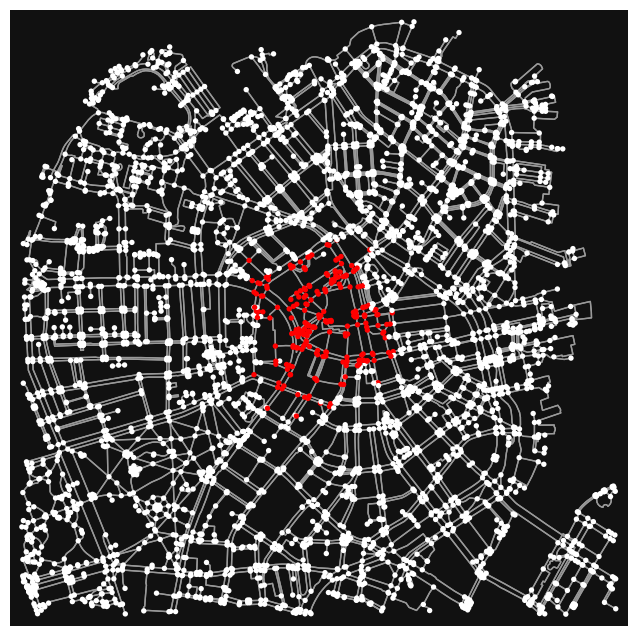

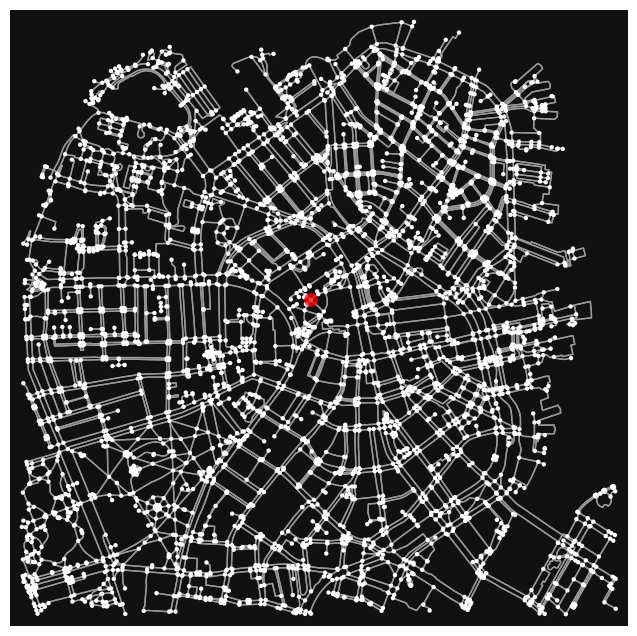

In [14]:

ox.plot_graph(G,node_color=["r" if n in nodes_within_x else "w" for n in G.nodes])
fig, ax = ox.plot_graph_route(G, [temp], route_color='red', route_linewidth=4, node_size=10, show=True, close=True)

In [ ]:
import numpy as np
new_graph = nx.generators.ego_graph(G, origin_node, radius=10)
print(new_graph.nodes)
print(G.nodes)
print([v for v in new_graph.nodes if v in G.nodes])
fig, ax = ox.plot(G, new_graph.nodes, route_color='red', route_linewidth=4, node_size=10, show=True, close=True)

def neighbors_in_radius(G, radius):
    adj = np.array(nx.linalg.graphmatrix.adjacency_matrix(G).todense()).astype(float)  # much faster as float
    power_adj = connected = adj
    for i in range(radius - 1):
        power_adj = power_adj.dot(adj)
        connected = connected + power_adj
    connected = connected.astype(bool).astype(int)
    return connected

print(neighbors_in_radius(G, 10))

[1618418692, 7838542853, 8744289806, 7619054094, 8744289810, 8744289811, 1411414555, 7335431197, 7619054117, 7619054118, 7619054120, 7619054121, 7619054122, 4776840747, 783962668, 328721454, 6162811438, 7675912751, 6162811439, 7675912755, 1411414581, 6162811445, 6162811447, 7675912758, 7198377017, 783962681, 7675912757, 7630761020, 783962677, 7630761017, 6162811455, 6162811456, 6162811458, 7630761027, 7630761026, 7367297092, 6162811462, 10181879367, 7367297093, 7335431244, 7335431248, 7335431249, 10181879377, 7335431251, 10181879380, 7335431253, 10181879378, 7335431256, 1411414616, 8741199448, 4776825440, 10181879394, 10181879396, 11823068772, 10181879397, 7335431269, 3909973948, 5212686958, 5212686959, 1411414653, 7838492294, 7838492297, 1411414671, 7838492307, 7838492311, 7838492312, 13121296028, 13121296029, 11752021662, 7838492319, 7838492320, 13305774239, 7838492322, 7838492324, 10184692908, 10184692909, 10184692911, 10199995568, 10199995570, 10199995571, 7335430837, 7335430838, 7

19.737973120533223
32.84721302338277
913.5508853361496
893.5167166018231
864.8594776658831
854.4861246887612
1034.8103203368398
999.7690197607227
1034.2269206045464
999.1856200284293
964.6001655807404
1066.047929828663
1125.0962016254837
1084.5096627418536
1051.2178153220023
1074.3851457610635
1064.420458371732
[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1830597846, 8038753707, 257734145, 8038753708, 8038753706, 257736893, 395134076, 1132394637, 1132394838, 257738711, 257735011, 257734149, 1830335477, 257736320, 257735712, 257735714, 257734771]


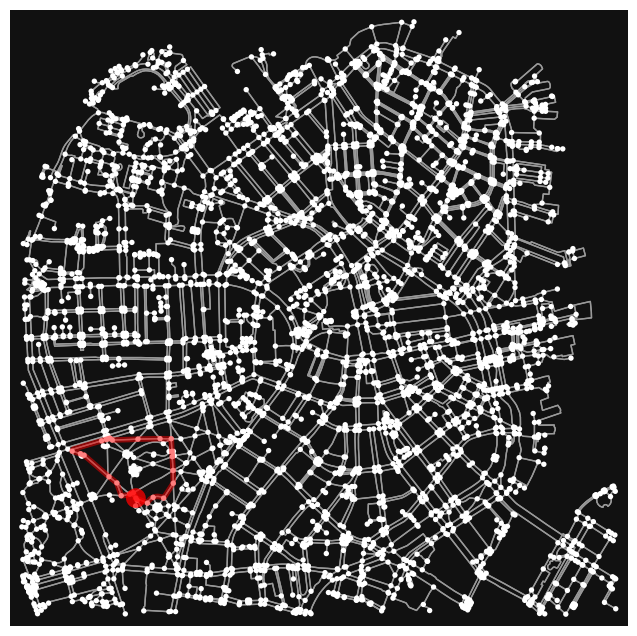

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1830597846, 8038753707, 7617222324, 7629281029, 7617222332, 7617345335, 7617345338, 257736826, 257736892, 257735012, 12348631346, 1132394723, 1830335477, 257736320, 257735712, 257735714, 257734771]


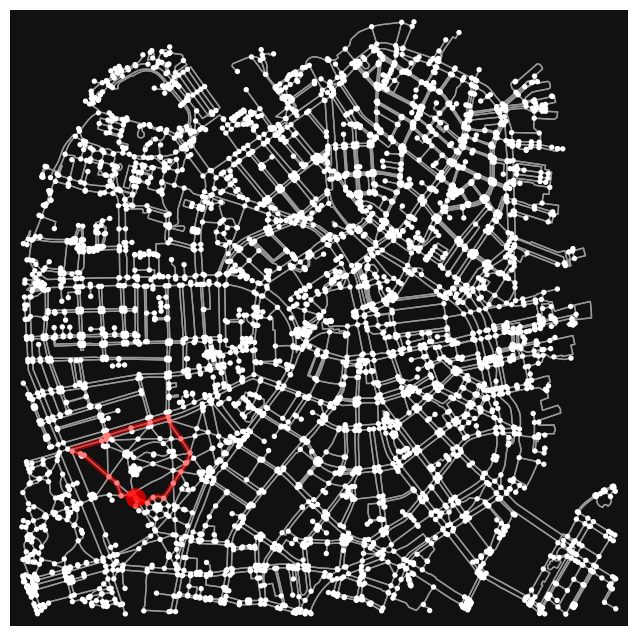

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1830597846, 8038753707, 7617222324, 7629281029, 7617222332, 7617345335, 7617345338, 257736826, 1132394838, 257738711, 257735011, 257734149, 1830335477, 257736320, 257735712, 257735714, 257734771]


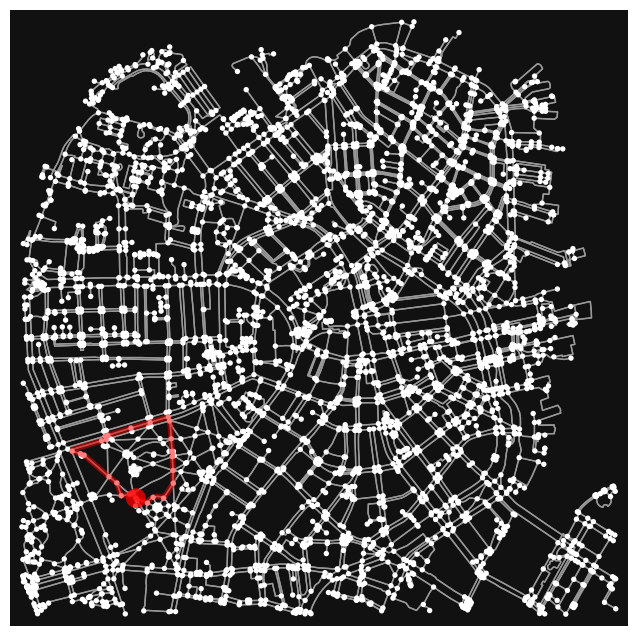

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1830597846, 8038753707, 7617222324, 7629281029, 7617222332, 7617345335, 257734236, 257736826, 257736892, 257735012, 12348631346, 1132394723, 1830335477, 257736320, 257735712, 257735714, 257734771]


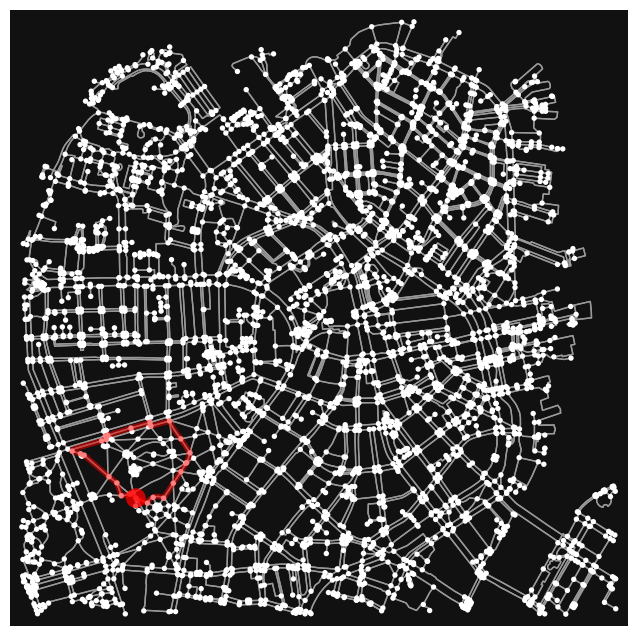

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1830597846, 8038753707, 7617222324, 7629281029, 7617222332, 7617345335, 257734236, 257736826, 1132394838, 257738711, 257735011, 257734149, 1830335477, 257736320, 257735712, 257735714, 257734771]


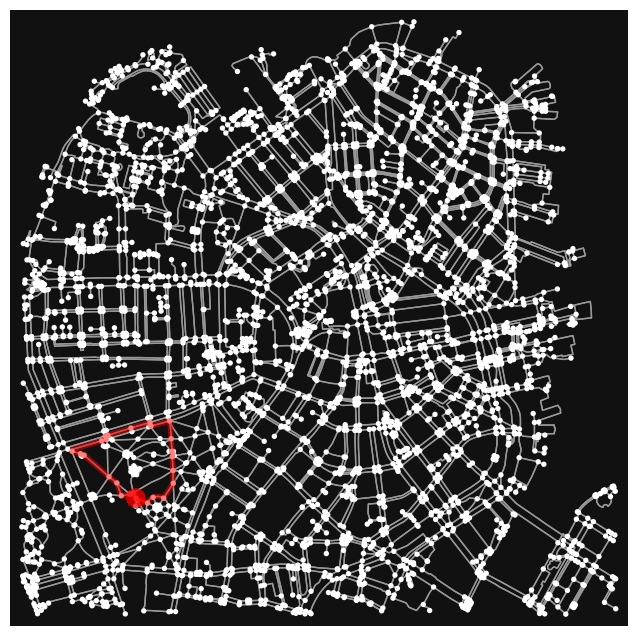

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1830597846, 8038753707, 7617222324, 7629281029, 7617222332, 7617345335, 257734236, 1132394637, 1132394838, 257738711, 257735011, 257734149, 1830335477, 257736320, 257735712, 257735714, 257734771]


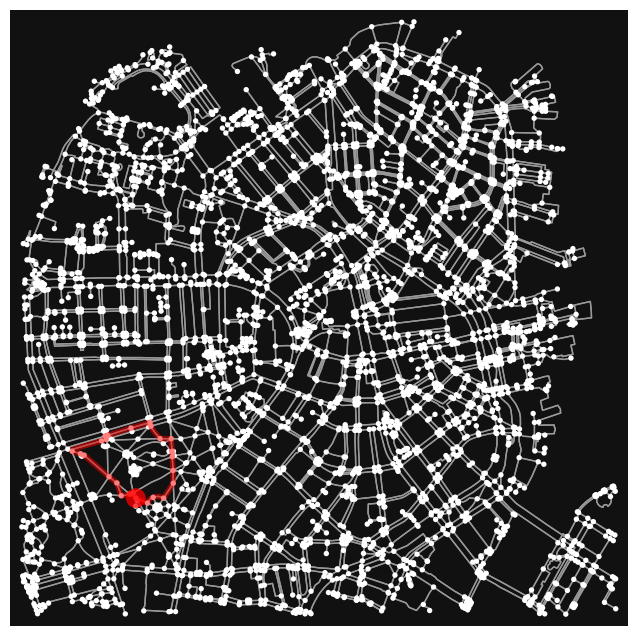

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1132394770, 7617222324, 7629281029, 7617222332, 7617345335, 7617345338, 257736826, 257736892, 257735012, 257735013, 12348631346, 1132394723, 1830335477, 257736320, 257735712, 257735714, 257734771]


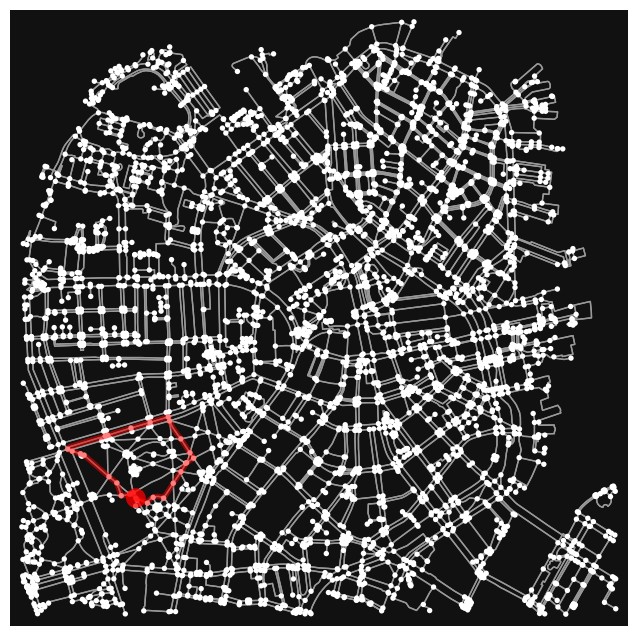

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1132394770, 7617222324, 7629281029, 7617222332, 7617345335, 7617345338, 257736826, 257736892, 257735012, 395132633, 257735011, 257734149, 1830335477, 257736320, 257735712, 257735714, 257734771]


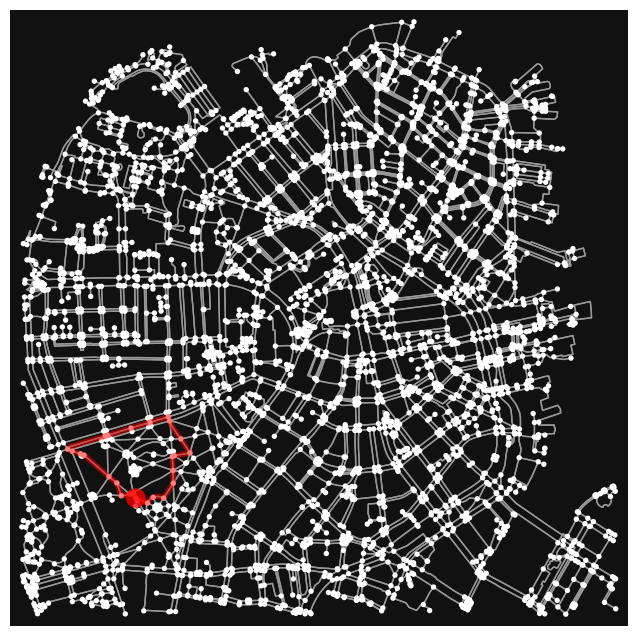

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1132394770, 7617222324, 7629281029, 7617222332, 7617345335, 7617345338, 257736826, 257736892, 257735012, 12348631346, 1132394723, 1830335477, 257736320, 257735712, 257735714, 257734771]


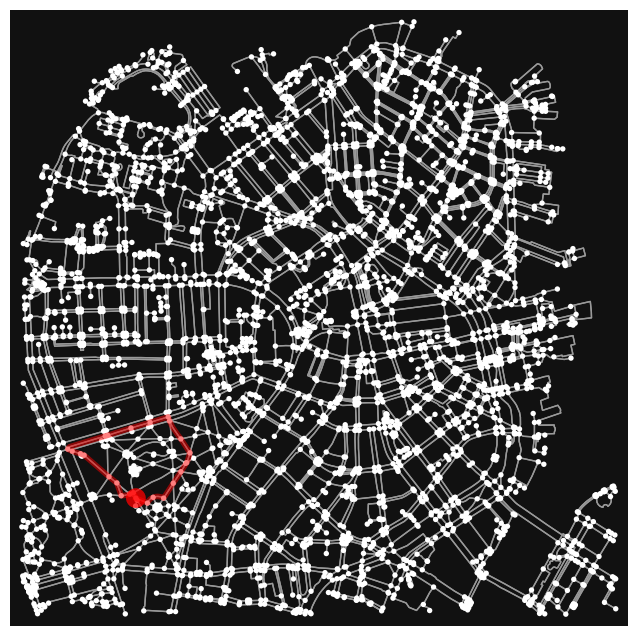

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1132394770, 7617222324, 7629281029, 7617222332, 7617345335, 7617345338, 257736826, 257736892, 257735012, 12348631346, 1132394723, 257734149, 1830335477, 257736320, 257735712, 257735714, 257734771]


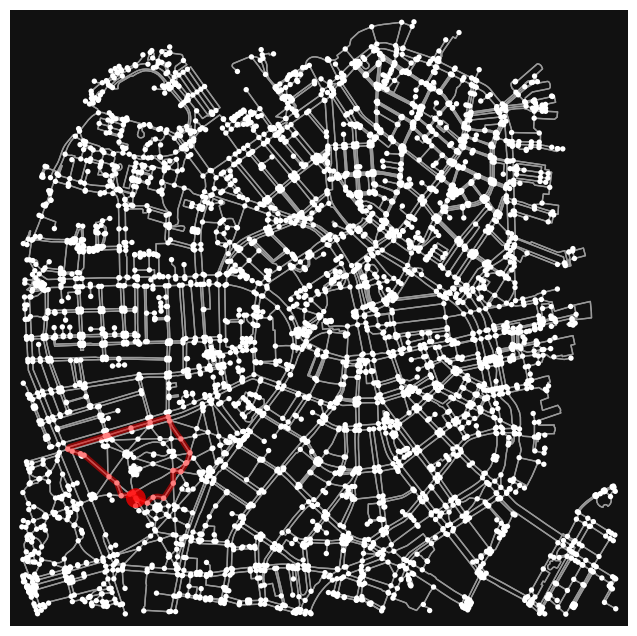

[257734771, 257735136, 7857637950, 257735138, 268233018, 242967779, 1830597818, 1830335480, 257734335, 1132394770, 7617222324, 7629281029, 7617222332, 7617345335, 7617345338, 257736826, 257736892, 257735012, 12348631346, 395132545, 257734149, 1830335477, 257736320, 257735712, 257735714, 257734771]


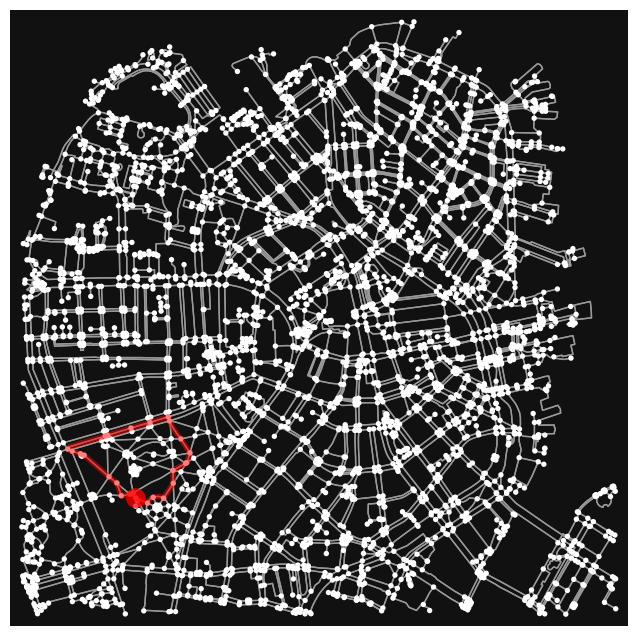

In [ ]:
edges = nx.find_cycle(G, source=origin_node)
simple_cylces = nx.simple_cycles(G, length_bound=25)
error = 100
target_distance = 1000
valid_cycles = []
for c in simple_cylces:
    length = 0
    if len(c) == 1:
        continue
    for i in range(1,len(c)):
        edges = G.get_edge_data(c[i],c[i-1])
        length += edges[0]['length']
    print(length)
    if target_distance - error < length < target_distance + error:
        valid_cycles.append(c + [c[0]])
        if len(valid_cycles) > 10:
            break

for c in valid_cycles:
    print(c)
    ox.plot_graph_route(G, c,orig_dest_size=200)